In [14]:
import numpy as np
from namap_main import load_par_file
import src.loaddata as ld
import src.detector as tod
import src.mapmaker as mp
import src.pointing as pt  
import copy
from astropy import wcs 
import astropy.table as tb
import h5py
import argparse
import ast
import sys
from astropy.table import Table
import matplotlib.pyplot as plt

#for debugging purpose only
from IPython import embed
from astropy.visualization import ZScaleInterval


#for profilling purpose only
import tracemalloc
import time

#Load the timestream at https://drive.google.com/file/d/1BnkEUj_yhPBPJte7ZgwxNHtMI75y8Nj6/view?usp=drive_link and place it in fits_and_hdf5/

#This notebook corresponds to the namap_main.py script to be runned with: python namap_main.py --params-file PAR_FILES/params_namap.par

In [3]:
P = load_par_file('PAR_FILES/params_namap.par')

_prec = str(P['precision'].lower()) #Select the precision: 64, 32 or 16B

num_frames, first_frame = P['num_frames'], P['first_frame'] #frames to be loaded
#1 frame is defined as 1 second of integration time. 

#Also need to be implemented. 
telemetry = P['telemetry']

#So far, only 'RA and DEC' is implemented and working.   

if P['input_ctype'] == 'RA and DEC':
    coord1 = str('RA')
    coord2 = str('DEC')
    xystage = False
elif P['input_ctype'] == 'AZ and EL':
    coord1 = str('AZ')
    coord2 = str('EL')
    xystage = False
elif P['input_ctype'] == 'CROSS-EL and EL':
    coord1 = str('xEL')
    coord2 = str('EL')
    xystage = False
elif P['input_ctype'] == 'XY Stage':
    coord1 = str('X')
    coord2 = str('Y')
    xystage = True


#Cleaning data parameters <-- needs to be tuned with real data
highpassfreq = P['highpassfreq']
polynomialorder = P['polynomialorder']
despike_bool = P['despike']
sigma,prominence = P['sigma'],P['prominence']
sigma_clipping_bool = ['sigma_clipping']
low_thresh, high_thresh = P['low_thresh'], P['high_thresh'] 
#Beam convolution parameters
convolution, std = P['gaussian_convolution'], P['std'] 
#---------------------------------


In [4]:
dtype_map = {
    '16': np.float16, 'float16': np.float16, 'half': np.float16,
    '32': np.float32, 'float32': np.float32, 'single': np.float32,
    '64': np.float64, 'float64': np.float64, 'double': np.float64
}

int_map = {
    '16': np.int16, 'float16': np.int16, 'half': np.int16,
    '32': np.int32, 'float32': np.int32, 'single': np.int32,
    '64': np.int64, 'float64': np.int64, 'double': np.int64
}

try:
    DT = dtype_map[_prec]
    IT = int_map[_prec]
except KeyError:
    raise ValueError(f"Unsupported precision '{_prec}'. Choose float16/32/64 or 16/32/64.")
print(f"Using numeric dtype: {DT}")

Using numeric dtype: <class 'numpy.float32'>


In [5]:
#Load the name of the KIDs to be analyse. 
filepath = P['hdf5_file']
btable = tb.Table.read(P['detector_table'], format='ascii.tab')

#If an electromagnetic frequency list is provided, then load all the detectors sensitive to them. 
if P['frequencies'] is not None:
    filtered = btable[np.isin(btable['Frequency'], P['frequencies'])]

#If a list of KID name is provided, load them
if P['detectors_to_use'] is not None:
    good_kid_table = tb.Table.read(P['detectors_to_use'], format='ascii.tab')
    filtered = btable[np.isin(btable['Name'], good_kid_table['Name'])]
if P['frequencies'] is None and P['detectors_to_use'] is None:
    filtered = btable
#option in the par file to good kids list

kid_num = filtered['Name']
#if(nbdets is not None): kid_num = filtered['Name'][:nbdets]
print('Nb dets: ', len(kid_num))

Nb dets:  64


In [6]:
#load the boresight offsets in CROSS-EL and EL of the selected detectors. 
dettable = ld.det_table(kid_num, P['detector_table']) 
det_off, _,_ = dettable.loadtable() #noise_det, resp

The number of samples loaded per frame for the detectors is: 488, and one frame is 1 second, so the spf is the rounded aquisition frequency


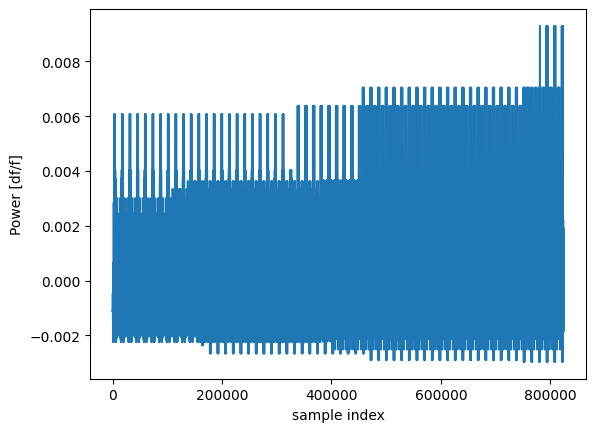

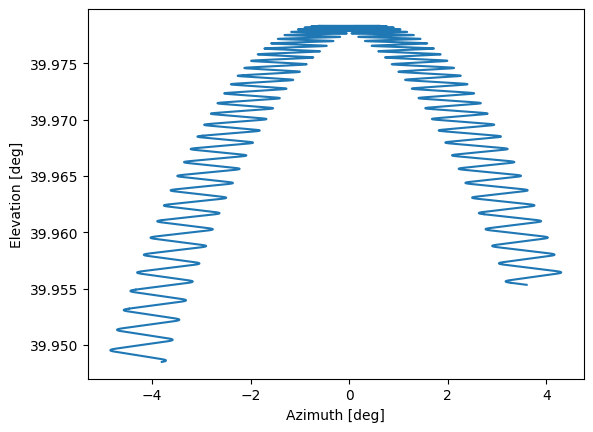

In [7]:
#load the timestreams and the coordinates. 
#----------------------------------
#Load the data
dataload = ld.data_value(filepath, kid_num, coord1, coord2, first_frame, num_frames,  DT, IT)
det_data, coord1_data, coord2_data, lst_data, lat_data, spf_data, spf_coord, lat_spf = dataload.values()
#-------------------------------

plt.plot(det_data[0])
plt.xlabel('sample index')
plt.ylabel('Power [df/f]')
plt.figure()
plt.plot(coord1_data, coord2_data,)

plt.xlabel('Azimuth [deg]')
plt.ylabel('Elevation [deg]')

print(f'The number of samples loaded per frame for the detectors is: {spf_data:.0f}, and one frame is 1 second, so the spf is the rounded aquisition frequency')

In [8]:
#---------------------------------
#First remove noise peaks and discard TODs with large & low variance. 
#Right now, fake data don't have noise or noise peaks (there are generated from an extragalactic sky simulation). 
det_tod = tod.data_cleaned(det_data, kid_num, det_off, spf_data,  0, 0, despike_bool, sigma, prominence, sigma_clipping_bool, low_thresh,high_thresh ,DT)
cleaned_data, kid_num, det_off, rejected_detetectors_list = det_tod.data_clean() 
P['rejected detectors list'] = rejected_detetectors_list #The list of rejected kids will be saved in the metadata of the .fits or the .hdf5 
#---------------------------------

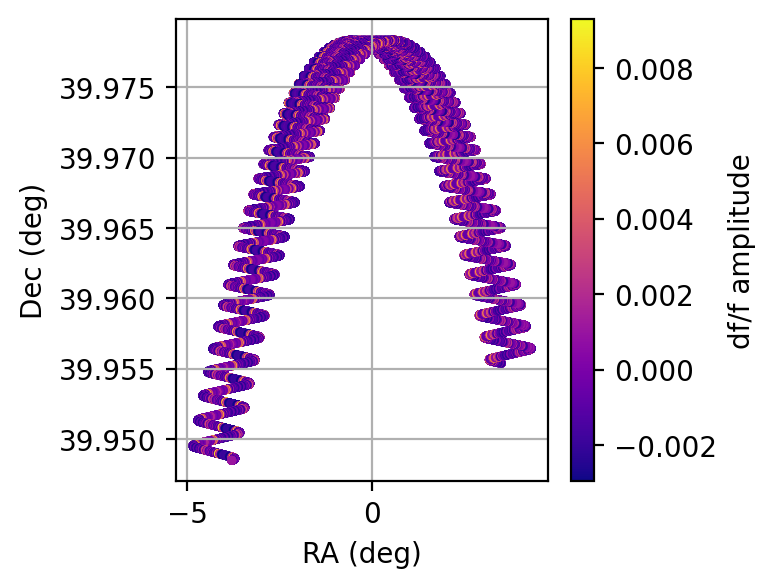

In [9]:
#Synchronize data with coordinates and downsample the timestreams to freq_target in Hz. 
zoomsyncdata = ld.frame_zoom_sync(filepath, cleaned_data, spf_data, coord1_data, coord2_data, spf_coord, first_frame, num_frames, 
                                    lst_data, lat_data,  lat_spf,  DT, IT, freq_target=P['downsample_frequency'])


timemap, cleaned_data, coord1_data, coord2_data, lst_data, lat_data, turnarounds_flag = zoomsyncdata.sync_data()  

# === Plot Az vs Alt with data amplitude as color ===
fig, ax = plt.subplots(figsize=(3,3), dpi=200)

sc = ax.scatter(coord1_data, coord2_data, c=cleaned_data[0], cmap='plasma', s=5)
# Attach colorbar to the left subplot (axs[0])
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.grid(True)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('df/f amplitude')

In [10]:
#---------------------------------
#Clean the TOD by removing smooth polynomial component and applying a high pass filter
det_tod = tod.data_cleaned(cleaned_data, kid_num, det_off, spf_data, highpassfreq, polynomialorder, False, 0, 0, False, 0,0, DT)
cleaned_data, _, _, _ = det_tod.data_clean()

#Filter out the turnarounds
if(P['remove_turnarounds']):
    for i in range(len(cleaned_data)): cleaned_data[i] = cleaned_data[i][turnarounds_flag==1]
    if P['save_downsampled_TODS']: timemap = timemap[turnarounds_flag==1]
    lst_data = lst_data[turnarounds_flag==1]
    lat_data = lat_data[turnarounds_flag==1]
    coord2_data = coord2_data[turnarounds_flag==1]
    coord1_data = coord1_data[turnarounds_flag==1] 

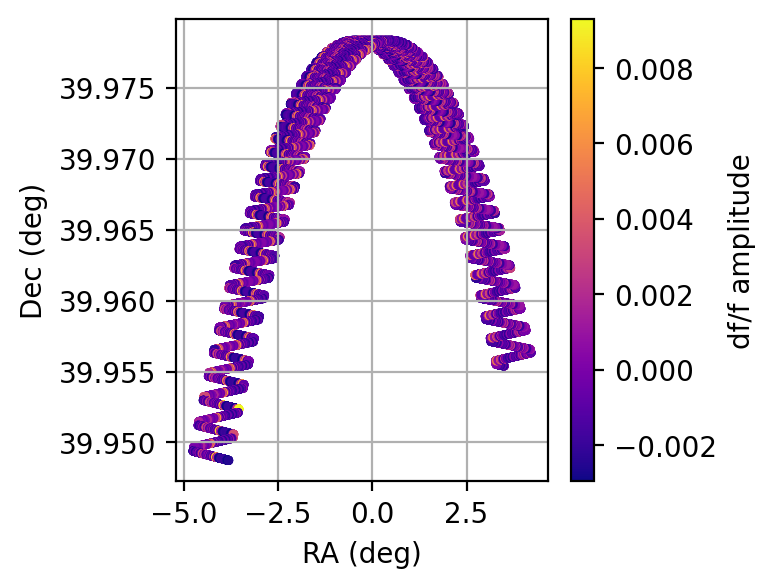

In [11]:
fig, ax = plt.subplots(figsize=(3,3), dpi=200)
sc = ax.scatter(coord1_data, coord2_data, c=cleaned_data[0], cmap='plasma', s=5)
# Attach colorbar to the left subplot (axs[0])
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.grid(True)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('df/f amplitude')

In [12]:
#Compress and save these cleaned TODs. 

tods_compressor = ld.compress_tods(P['output_hdf5'], kid_num, cleaned_data, P['downsample_frequency'], timemap, 
                                    coord1, coord2, coord1_data, coord2_data, 
                                    first_frame, num_frames, lst_data, lat_data,P,
                                    DT, IT, int8=P['int8'])
tods_compressor.save_tods()


Opened existing file: fits_and_hdf5/tods.hdf5


0

Text(0, 0.5, 'Dec (deg)')

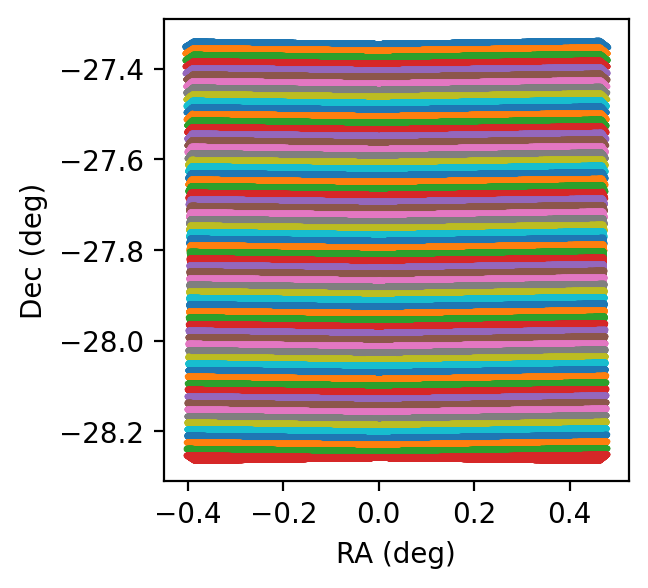

In [13]:
#Compute the RA and DEC

#---------------------------------
#Offset with respect to star cameras in xEL and EL
xsc_offset = (P['xsc_offset'],P['det_offset']) #needs to be tested with real offsets. 
#xsc_file = ld.xsc_offset(P['pointing_table'], first_frame, num_frames+first_frame)
#xsc_offset = xsc_file.read_file()

corr = pt.apply_offset(P['input_ctype'], coord1_data, coord2_data, P['ctype'], xsc_offset, DT,IT, det_offset = det_off, lst = lst_data, lat = lat_data, )
coord1slice, coord2slice = corr.correction()
#---------------------------------

fig, ax = plt.subplots(figsize=(3,3), dpi=200)
for i in range(len(coord1slice)): 
    sc = ax.scatter(coord1slice[i], coord2slice[i], s=1)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:398: RuntimeWarning: invalid value encountered in divide
  hist /= norm


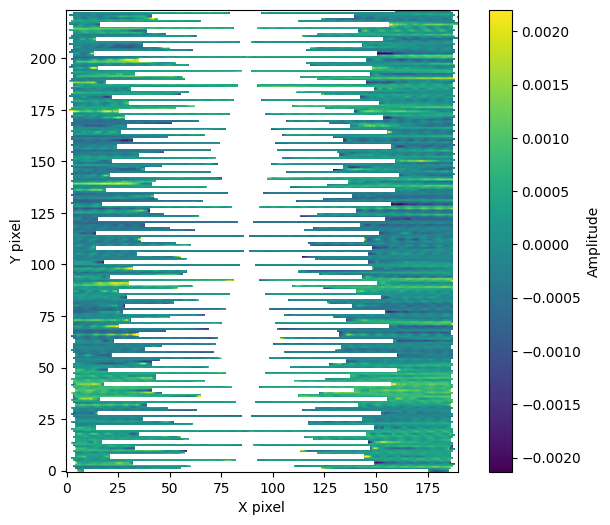

In [15]:
# create the maps and save them in fits_and_hdf5/ 
#--------------------
coadd = True #If True, coadd all detectors into one map. Else, save individual detector maps. 
#-------------------
parallactic=[]
if P['telescope_coordinate']:
    for j, (c1, c2) in enumerate(zip(coord1slice,coord2slice)): 
        tel = pt.utils(c1, c2, lst_data, lat_data)
        parallactic.append( tel.parallactic_angle() )
else:
    for j, (c1, c2) in enumerate(zip(coord1slice,coord2slice)): 
        parallactic.append(np.zeros_like(c1, dtype=DT))

#---------------------------------

#--------------------
#Create the maps
maps = mp.maps(P['ctype'], 
            np.asarray([P['crpix'][0],P['crpix'][1]]), 
            np.asarray([P['cdelt'][0],P['cdelt'][1]]), 
            np.asarray([P['crval'][0], P['crval'][1]]), 
            np.asarray([P['pixnum'][0],P['pixnum'][1]]), 
            cleaned_data, coord1slice, coord2slice, convolution, std, P['output_map'], DT,IT,
            coadd=coadd,   parang=parallactic, params=str(P)) #noise=noise_det,telcoord = P['telescope_coordinate'],

maps.wcs_proj()
map_values = maps.map2d()
#--------------------

zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(map_values)
plt.figure(figsize=(8, 6))
plt.imshow(map_values, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(label='Amplitude')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.show()